<a href="https://colab.research.google.com/github/nauerromero/Ciencia_de_Datos_II/blob/main/CasoPractico1_Punto3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3- Correr varios escenarios de Ensamble al dataset Iris (de skalearn)

Bagging Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

AdaBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
  

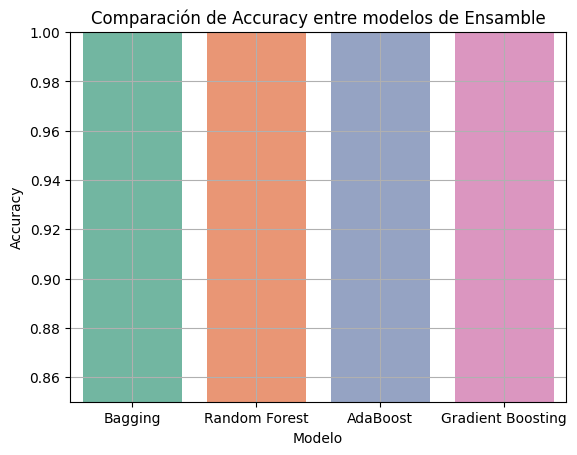

Resumen comparativo:
              Modelo  Accuracy
0            Bagging       1.0
1      Random Forest       1.0
2           AdaBoost       1.0
3  Gradient Boosting       1.0


In [ ]:
!pip install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Cargar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo 1: Bagging con Árboles de Decisión
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, max_samples=0.8, bootstrap=True, random_state=42)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)
print("Bagging Accuracy:", acc_bag)
print(classification_report(y_test, y_pred_bag))

# Modelo 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

# Modelo 3: AdaBoost
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", acc_ada)
print(classification_report(y_test, y_pred_ada))

# Modelo 4: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", acc_gb)
print(classification_report(y_test, y_pred_gb))

# Comparación de resultados
resultados = pd.DataFrame({
    "Modelo": ["Bagging", "Random Forest", "AdaBoost", "Gradient Boosting"],
    "Accuracy": [acc_bag, acc_rf, acc_ada, acc_gb]
})

sns.barplot(data=resultados, x="Modelo", y="Accuracy", hue="Modelo", palette="Set2", legend=False)

plt.title("Comparación de Accuracy entre modelos de Ensamble")
plt.ylim(0.85, 1.0)
plt.grid(True)
plt.show()

print("Resumen comparativo:")
print(resultados.sort_values(by="Accuracy", ascending=False))